# Order Delivery Time Prediction

## Objectives
The objective of this assignment is to build a regression model that predicts the delivery time for orders placed through Porter. The model will use various features such as the items ordered, the restaurant location, the order protocol, and the availability of delivery partners.

The key goals are:
- Predict the delivery time for an order based on multiple input features
- Improve delivery time predictions to optimiae operational efficiency
- Understand the key factors influencing delivery time to enhance the model's accuracy

## Data Pipeline
The data pipeline for this assignment will involve the following steps:
1. **Data Loading**
2. **Data Preprocessing and Feature Engineering**
3. **Exploratory Data Analysis**
4. **Model Building**
5. **Model Inference**

## Data Understanding
The dataset contains information on orders placed through Porter, with the following columns:

| Field                     | Description                                                                                 |
|---------------------------|---------------------------------------------------------------------------------------------|
| market_id                 | Integer ID representing the market where the restaurant is located.                         |
| created_at                | Timestamp when the order was placed.                                                        |
| actual_delivery_time      | Timestamp when the order was delivered.                                                     |
| store_primary_category    | Category of the restaurant (e.g., fast food, dine-in).                                      |
| order_protocol            | Integer representing how the order was placed (e.g., via Porter, call to restaurant, etc.). |
| total_items               | Total number of items in the order.                                                         |
| subtotal                  | Final price of the order.                                                                   |
| num_distinct_items        | Number of distinct items in the order.                                                      |
| min_item_price            | Price of the cheapest item in the order.                                                    |
| max_item_price            | Price of the most expensive item in the order.                                              |
| total_onshift_dashers     | Number of delivery partners on duty when the order was placed.                              |
| total_busy_dashers        | Number of delivery partners already occupied with other orders.                             |
| total_outstanding_orders  | Number of orders pending fulfillment at the time of the order.                              |
| distance                  | Total distance from the restaurant to the customer.                                         |


## **Importing Necessary Libraries**

In [15]:
# Import essential libraries for data manipulation and analysis
import pandas as pd
import numpy as np

# Import libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")


## **1. Loading the data**
Load 'porter_data_1.csv' as a DataFrame

In [17]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [16]:
# Importing the file porter_data_1.csv
porter_data = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Delivery_Starter (1)/porter_data_1.csv")

## **2. Data Preprocessing and Feature Engineering** <font color = red>[15 marks]</font> <br>

#### **2.1 Fixing the Datatypes**  <font color = red>[5 marks]</font> <br>
The current timestamps are in object format and need conversion to datetime format for easier handling and intended functionality

##### **2.1.1** <font color = red>[2 marks]</font> <br>
Convert date and time fields to appropriate data type

In [18]:
# Convert 'created_at' and 'actual_delivery_time' columns to datetime format
porter_data['created_at'] = pd.to_datetime(porter_data['created_at'])
porter_data['actual_delivery_time'] = pd.to_datetime(porter_data['actual_delivery_time'])

##### **2.1.2**  <font color = red>[3 marks]</font> <br>
Convert categorical fields to appropriate data type

In [19]:
# Convert categorical features to category type
porter_data[['store_primary_category', 'order_protocol']] = porter_data[['store_primary_category', 'order_protocol']].astype('category')


#### **2.2 Feature Engineering** <font color = red>[5 marks]</font> <br>
Calculate the time taken to execute the delivery as well as extract the hour and day at which the order was placed

##### **2.2.1** <font color = red>[2 marks]</font> <br>
Calculate the time taken using the features `actual_delivery_time` and `created_at`

In [20]:
# Calculate time taken in minutes
porter_data['delivery_time_min'] = (porter_data['actual_delivery_time'] - porter_data['created_at']).dt.seconds / 60

##### **2.2.2** <font color = red>[3 marks]</font> <br>
Extract the hour at which the order was placed and which day of the week it was. Drop the unnecessary columns.

In [21]:
# Extract the hour and day of week from the 'created_at' timestamp
porter_data['hour'] = porter_data['created_at'].dt.hour
porter_data['dayofweek'] = porter_data['created_at'].dt.dayofweek

# Create a categorical feature 'isWeekend'
porter_data['isWeekend'] = (porter_data['dayofweek'] >= 5).astype(int)


In [22]:
# Drop unnecessary columns
porter_data.drop(['created_at', 'actual_delivery_time'], axis=1, inplace=True)

#### **2.3 Creating training and validation sets** <font color = red>[5 marks]</font> <br>

##### **2.3.1** <font color = red>[2 marks]</font> <br>
 Define target and input features

In [23]:
# Define target variable (y) and features (X)
y = porter_data['delivery_time_min']
X = porter_data[['subtotal', 'total_onshift_dashers', 'total_busy_dashers',
                 'total_outstanding_orders', 'distance']]


##### **2.3.2** <font color = red>[3 marks]</font> <br>
 Split the data into training and test sets

In [24]:
# Split data into training and testing sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


## **3. Exploratory Data Analysis on Training Data** <font color = red>[20 marks]</font> <br>
1. Analyzing the correlation between variables to identify patterns and relationships
2. Identifying and addressing outliers to ensure the integrity of the analysis
3. Exploring the relationships between variables and examining the distribution of the data for better insights

#### **3.1 Feature Distributions** <font color = red> [7 marks]</font> <br>


In [25]:
# Define numerical and categorical columns for easy EDA and data manipulation
numerical_col = porter_data.select_dtypes('number').columns
categ_col = porter_data.select_dtypes('object').columns


##### **3.1.1** <font color = red>[3 marks]</font> <br>
Plot distributions for numerical columns in the training set to understand their spread and any skewness

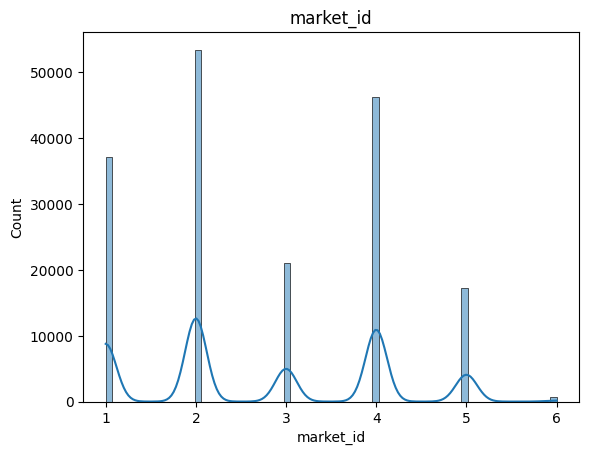

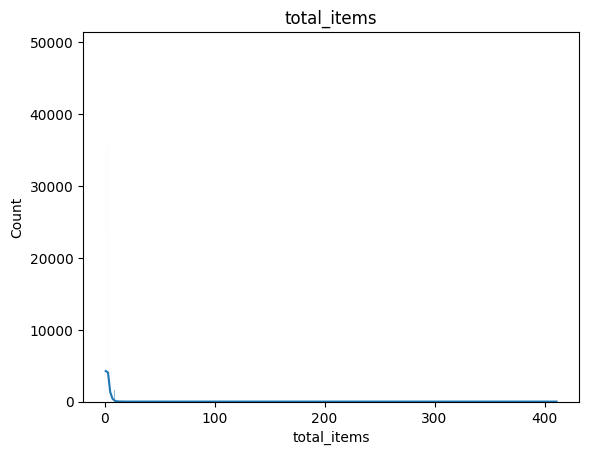

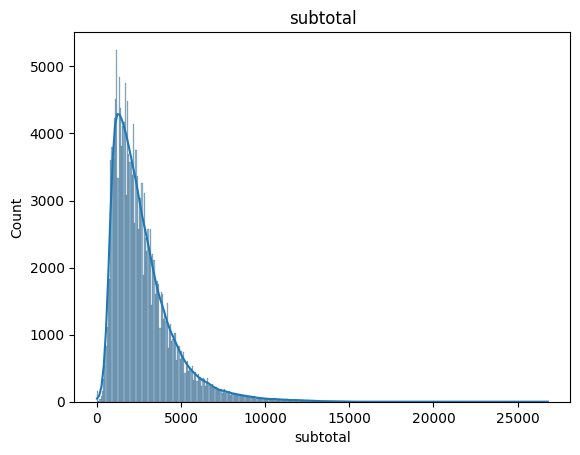

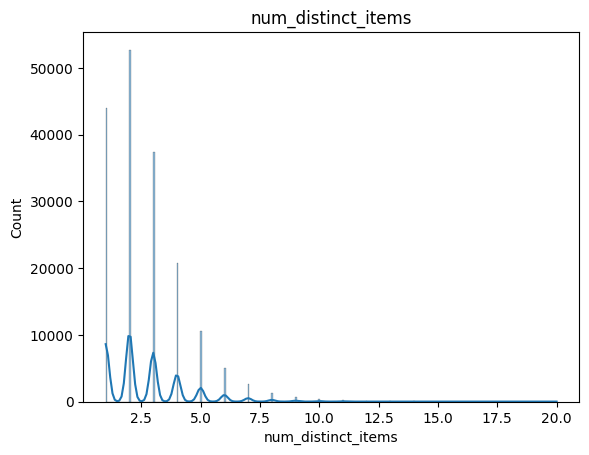

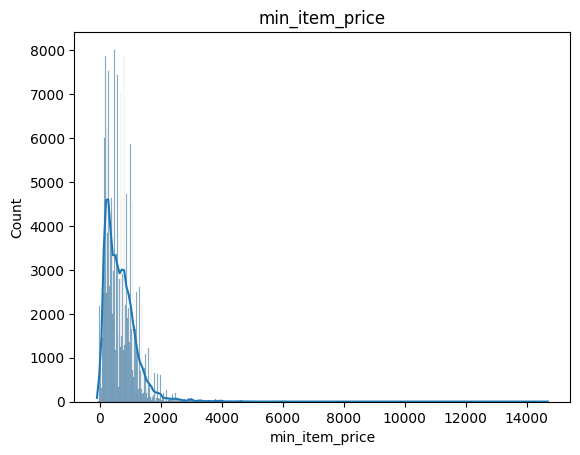

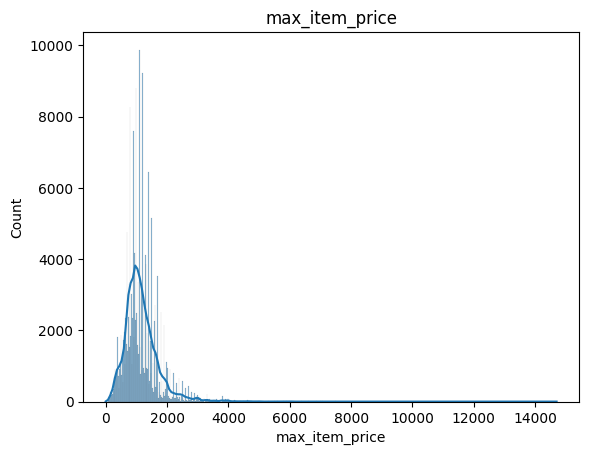

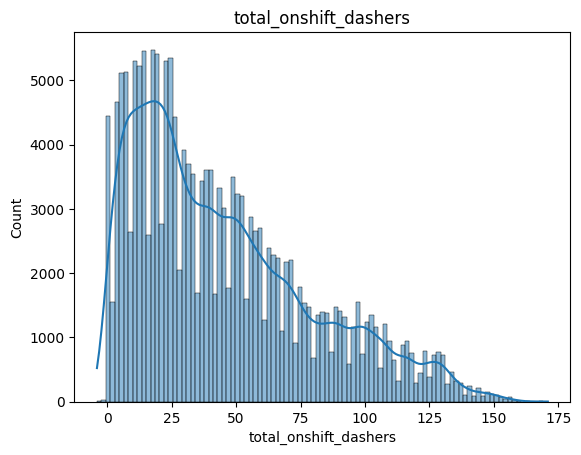

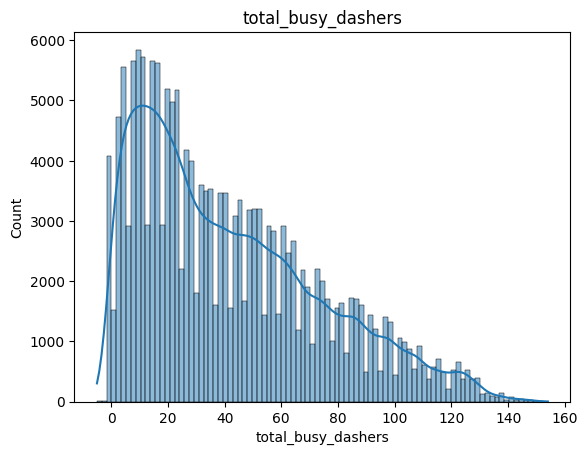

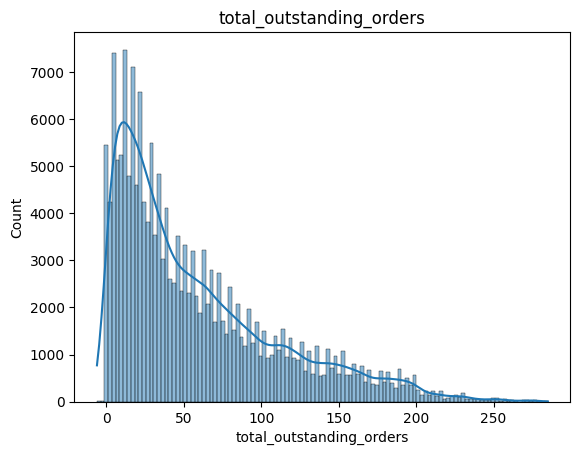

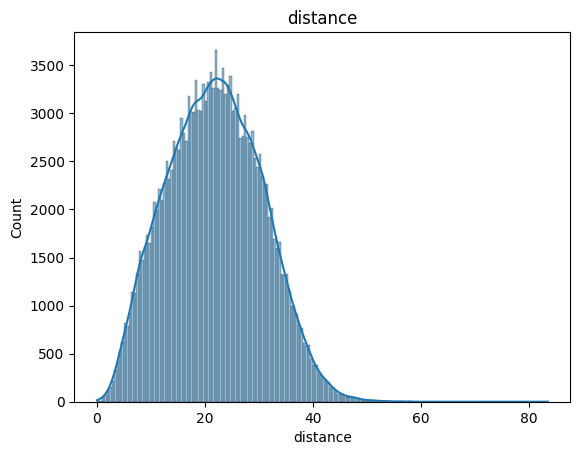

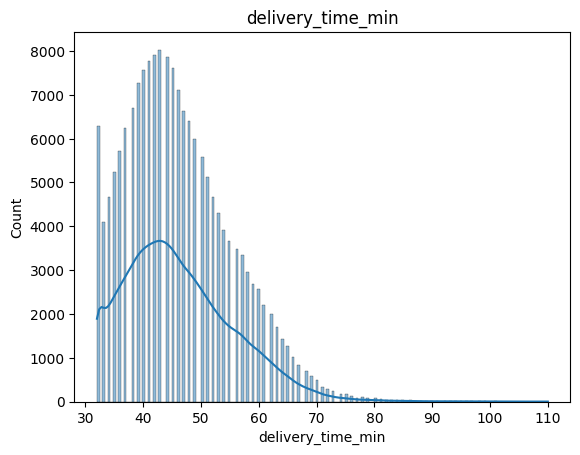

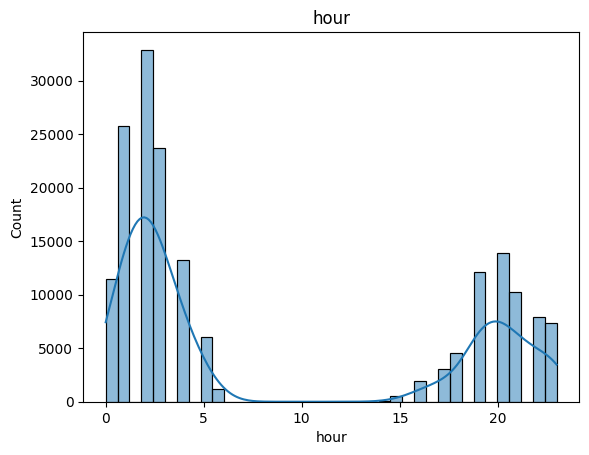

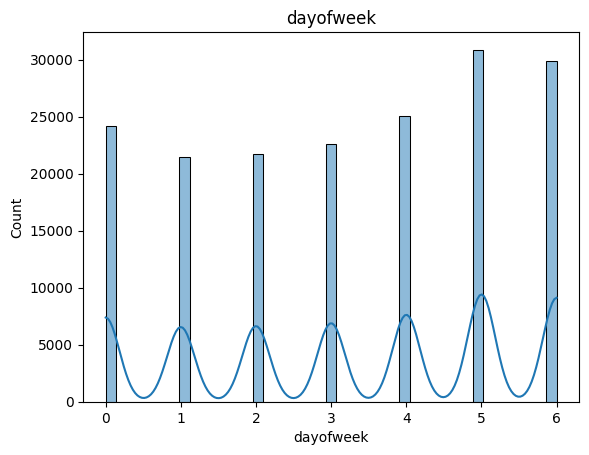

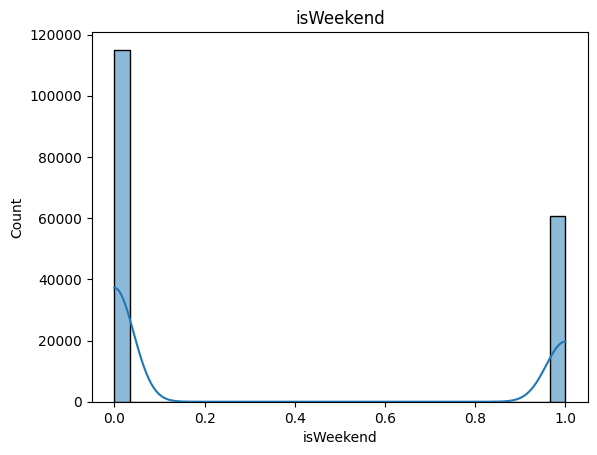

In [26]:
# Plot distributions for all numerical columns

for col in numerical_col:
    sns.histplot(porter_data[col], kde=True)
    plt.title(col)
    plt.show()


##### **3.1.2** <font color = red>[2 marks]</font> <br>
Check the distribution of categorical features

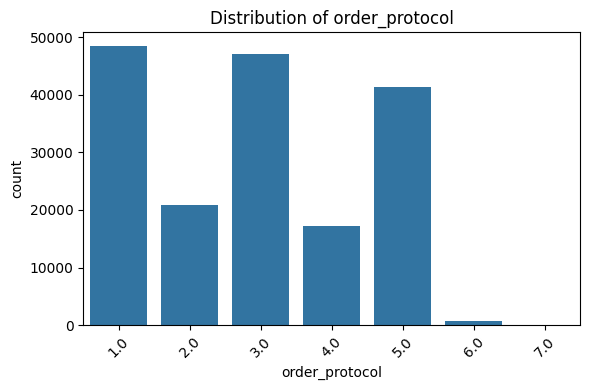

In [27]:
# Distribution of categorical columns
for col in porter_data.select_dtypes(include=['object', 'category']):
    if porter_data[col].nunique() < 20:
        plt.figure(figsize=(6, 4))
        sns.countplot(x=col, data=porter_data)
        plt.title(f"Distribution of {col}")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()


##### **3.1.3** <font color = red>[2 mark]</font> <br>
Visualise the distribution of the target variable to understand its spread and any skewness

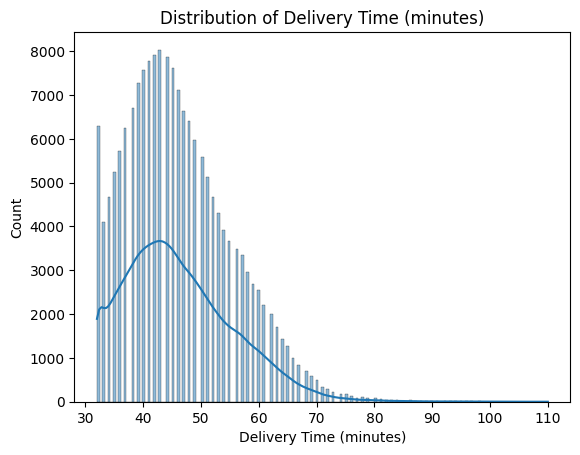

In [28]:
# Distribution of time_taken
sns.histplot(porter_data['delivery_time_min'], kde=True)
plt.title('Distribution of Delivery Time (minutes)')
plt.xlabel('Delivery Time (minutes)')
plt.show()


#### **3.2 Relationships Between Features** <font color = red>[3 marks]</font> <br>

##### **3.2.1** <font color = red>[3 marks]</font> <br>
Scatter plots for important numerical and categorical features to observe how they relate to `time_taken`

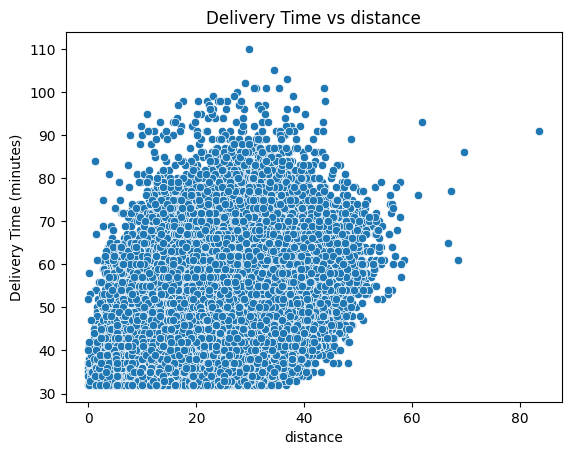

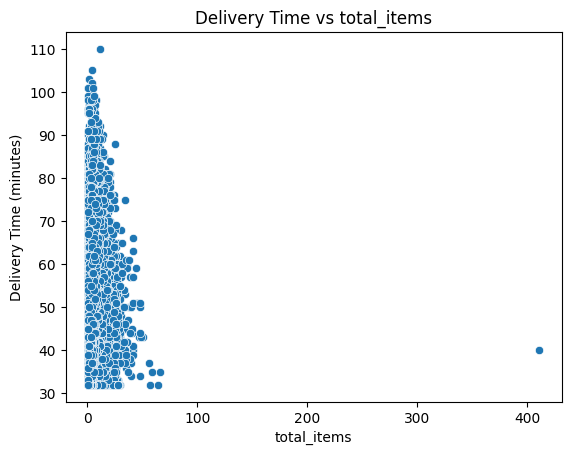

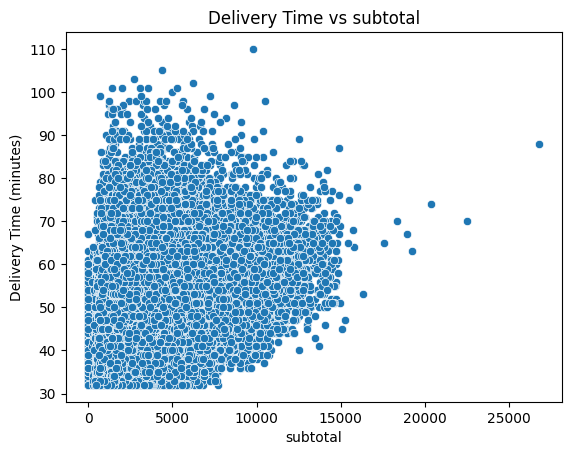

In [29]:
# Scatter plot to visualise the relationship between time_taken and other features
features = ['distance', 'total_items', 'subtotal']  # choose features you want to compare

for col in features:
    sns.scatterplot(x=porter_data[col], y=porter_data['delivery_time_min'])
    plt.title(f'Delivery Time vs {col}')
    plt.xlabel(col)
    plt.ylabel('Delivery Time (minutes)')
    plt.show()


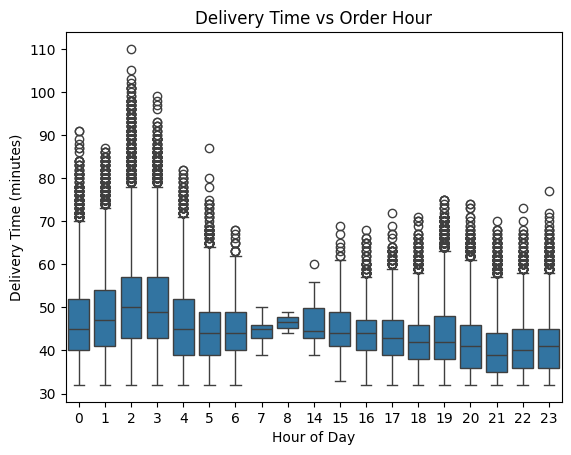

In [30]:
# Show the distribution of time_taken for different hours
sns.boxplot(x='hour', y='delivery_time_min', data=porter_data)
plt.title('Delivery Time vs Order Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Delivery Time (minutes)')
plt.show()



#### **3.3 Correlation Analysis** <font color = red>[5 marks]</font> <br>
Check correlations between numerical features to identify which variables are strongly related to `time_taken`

##### **3.3.1** <font color = red>[3 marks]</font> <br>
Plot a heatmap to display correlations

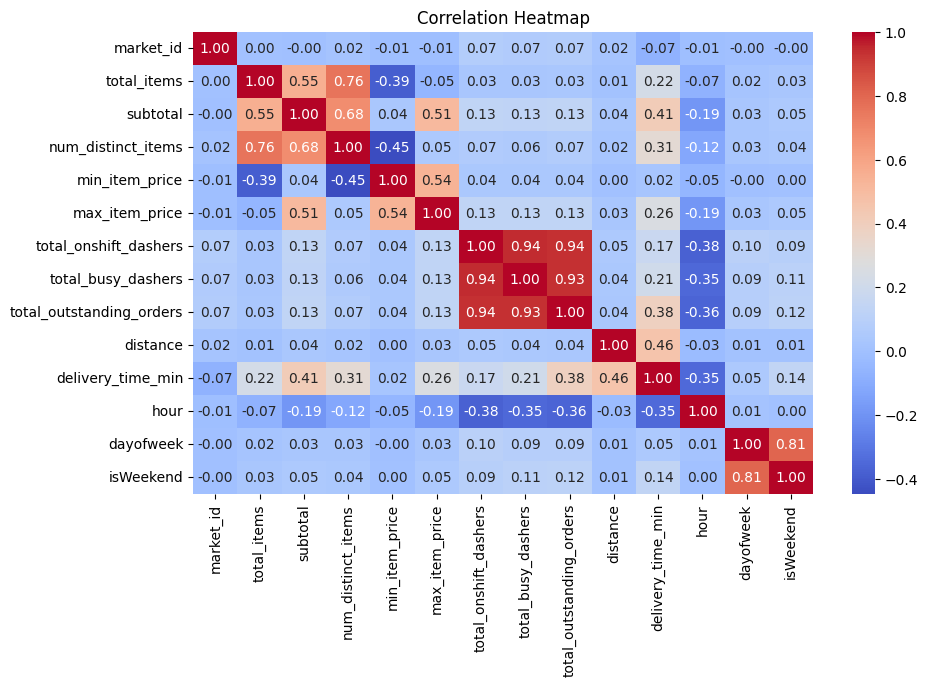

In [31]:
# Plot the heatmap of the correlation matrix
plt.figure(figsize=(10, 6))
sns.heatmap(porter_data.corr(numeric_only=True), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

##### **3.3.2** <font color = red>[2 marks]</font> <br>
Drop the columns with weak correlations with the target variable

In [32]:
# Drop 3-5 weakly correlated columns from training dataset
porter_data.drop(columns=[
    'market_id',
    'total_items',
    'min_item_price',
    'dayofweek'
], inplace=True)



#### **3.4 Handling the Outliers** <font color = red>[5 marks]</font> <br>



##### **3.4.1** <font color = red>[2 marks]</font> <br>
Visualise potential outliers for the target variable and other numerical features using boxplots

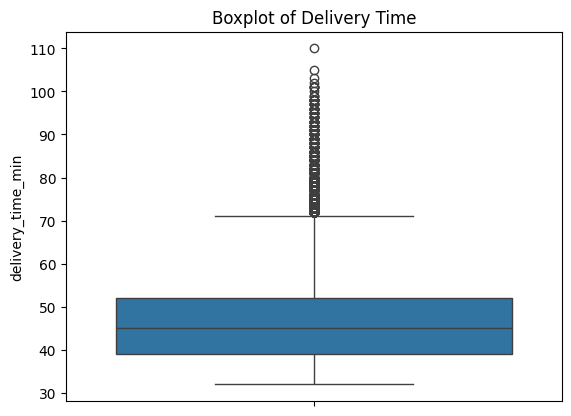

In [33]:
# Boxplot for time_taken
sns.boxplot(y=porter_data['delivery_time_min'])
plt.title('Boxplot of Delivery Time')
plt.show()



##### **3.4.2** <font color = red>[3 marks]</font> <br>
Handle outliers present in all columns

In [34]:
# Handle outliers
q1, q3 = porter_data['delivery_time_min'].quantile([0.25, 0.75])
iqr = q3 - q1
porter_data = porter_data[(porter_data['delivery_time_min'] >= q1 - 1.5*iqr) &
                          (porter_data['delivery_time_min'] <= q3 + 1.5*iqr)]

## **4. Exploratory Data Analysis on Validation Data** <font color = red>[optional]</font> <br>
Optionally, perform EDA on test data to see if the distribution match with the training data

In [35]:
# Define numerical and categorical columns for easy EDA and data manipulation



#### **4.1 Feature Distributions**


##### **4.1.1**
Plot distributions for numerical columns in the validation set to understand their spread and any skewness

In [36]:
# Plot distributions for all numerical columns



##### **4.1.2**
Check the distribution of categorical features

In [37]:
# Distribution of categorical columns



##### **4.1.3**
Visualise the distribution of the target variable to understand its spread and any skewness

In [38]:
# Distribution of time_taken



#### **4.2 Relationships Between Features**
Scatter plots for numerical features to observe how they relate to each other, especially to `time_taken`

In [39]:
# Scatter plot to visualise the relationship between time_taken and other features



#### **4.3** Drop the columns with weak correlations with the target variable

In [40]:
# Drop the weakly correlated columns from training dataset



## **5. Model Building** <font color = red>[15 marks]</font> <br>

#### **Import Necessary Libraries**

In [41]:
# Import libraries
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.feature_selection import RFE
from sklearn.linear_model import LinearRegression

#### **5.1 Feature Scaling** <font color = red>[3 marks]</font> <br>

In [42]:
print(porter_data.columns.tolist())
numerical_col = [
    'subtotal',
    'num_distinct_items',
    'max_item_price',
    'total_onshift_dashers',
    'total_busy_dashers',
    'total_outstanding_orders',
    'distance',
    'hour'
]

['store_primary_category', 'order_protocol', 'subtotal', 'num_distinct_items', 'max_item_price', 'total_onshift_dashers', 'total_busy_dashers', 'total_outstanding_orders', 'distance', 'delivery_time_min', 'hour', 'isWeekend']


In [43]:
# Apply scaling to the numerical columns
scaler = StandardScaler()
porter_data[numerical_col] = scaler.fit_transform(porter_data[numerical_col])



Note that linear regression is agnostic to feature scaling. However, with feature scaling, we get the coefficients to be somewhat on the same scale so that it becomes easier to compare them.

#### **5.2 Build a linear regression model** <font color = red>[5 marks]</font> <br>

You can choose from the libraries *statsmodels* and *scikit-learn* to build the model.

In [44]:
# Create/Initialise the model
model = LinearRegression()


In [45]:
print(porter_data.columns.tolist())
features = ['order_protocol', 'subtotal', 'num_distinct_items', 'max_item_price',
            'total_onshift_dashers', 'total_busy_dashers', 'total_outstanding_orders',
            'distance', 'hour', 'isWeekend']

['store_primary_category', 'order_protocol', 'subtotal', 'num_distinct_items', 'max_item_price', 'total_onshift_dashers', 'total_busy_dashers', 'total_outstanding_orders', 'distance', 'delivery_time_min', 'hour', 'isWeekend']


In [46]:
# Train the model using the training data
from sklearn.model_selection import train_test_split



X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model.fit(X_train, y_train)

LinearRegression()

In [47]:
model.fit(X_train, y_train)

LinearRegression()

In [48]:
# Make predictions
y_pred = model.predict(X_test)
print(y_pred[:5])  # show first 5 predictions



[46.83408231 67.51790268 39.94913961 46.95395433 43.57535914]


In [49]:
# Find results for evaluation metrics
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R²:", r2_score(y_test, y_pred))


MAE: 3.146942550311183
RMSE: 4.110976277715283
R²: 0.8069159104589869


Note that we have 12 (depending on how you select features) training features. However, not all of them would be useful. Let's say we want to take the most relevant 8 features.

We will use Recursive Feature Elimination (RFE) here.

For this, you can look at the coefficients / p-values of features from the model summary and perform feature elimination, or you can use the RFE module provided with *scikit-learn*.

#### **5.3 Build the model and fit RFE to select the most important features** <font color = red>[7 marks]</font> <br>

For RFE, we will start with all features and use
the RFE method to recursively reduce the number of features one-by-one.

After analysing the results of these iterations, we select the one that has a good balance between performance and number of features.

In [50]:
# Loop through the number of features and test the model
for i in range(1, len(X_train.columns) + 1):
    rfe = RFE(LinearRegression(), n_features_to_select=i)
    rfe.fit(X_train, y_train)
    r2 = rfe.score(X_test, y_test)
    print(f"{i} features: R² = {r2:.3f}")


1 features: R² = 0.209
2 features: R² = 0.231
3 features: R² = 0.649
4 features: R² = 0.674
5 features: R² = 0.807


In [51]:
# Build the final model with selected number of features
rfe = RFE(LinearRegression(), n_features_to_select=5)
rfe.fit(X_train, y_train)

selected = X_train.columns[rfe.support_]
model = LinearRegression()
model.fit(X_train[selected], y_train)


LinearRegression()

## **6. Results and Inference** <font color = red>[5 marks]</font> <br>

#### **6.1 Perform Residual Analysis** <font color = red>[3 marks]</font> <br>

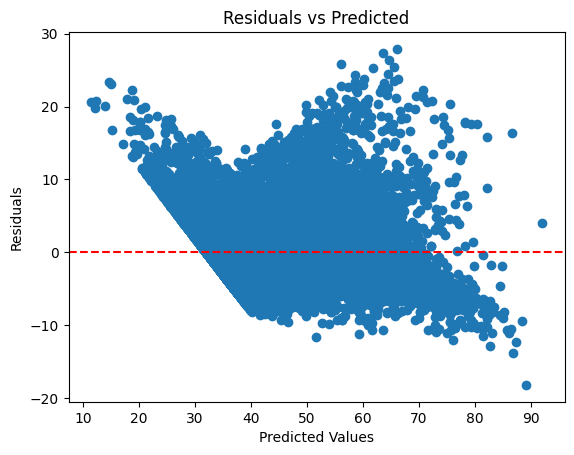

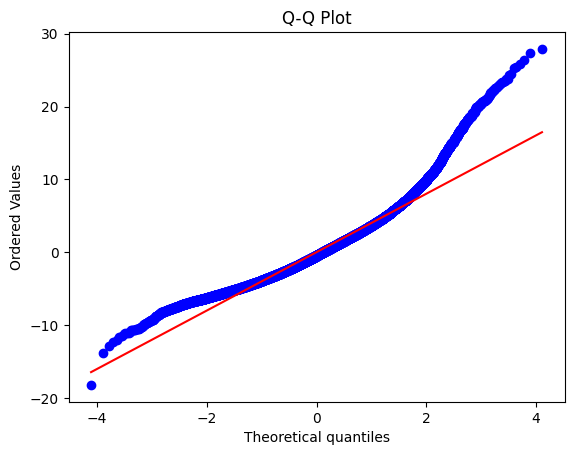

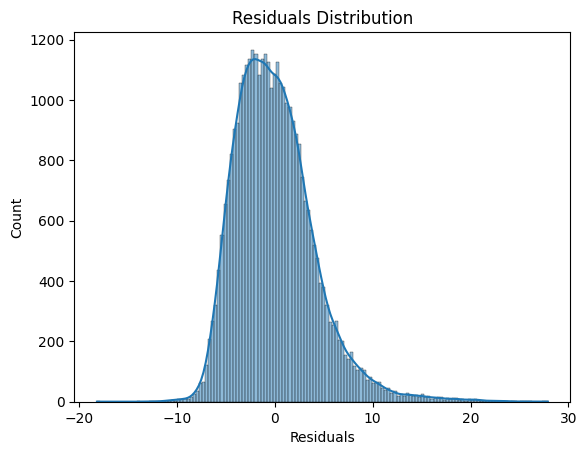

In [52]:
# Perform residual analysis using plots like residuals vs predicted values, Q-Q plot and residual histogram
y_pred = model.predict(X_test[selected])
residuals = y_test - y_pred

# residuals vs predicted values
plt.scatter(y_pred, residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted")
plt.show()

# Q-Q plot
import scipy.stats as stats

stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Q-Q Plot")
plt.show()

# residual histogram
sns.histplot(residuals, kde=True)
plt.title("Residuals Distribution")
plt.xlabel("Residuals")
plt.show()


[Your inferences here:]



#### **6.2 Perform Coefficient Analysis** <font color = red>[2 marks]</font> <br>

Perform coefficient analysis to find how changes in features affect the target.
Also, the features were scaled, so interpret the scaled and unscaled coefficients to understand the impact of feature changes on delivery time.


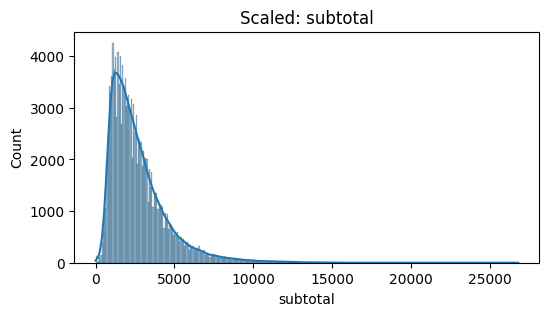

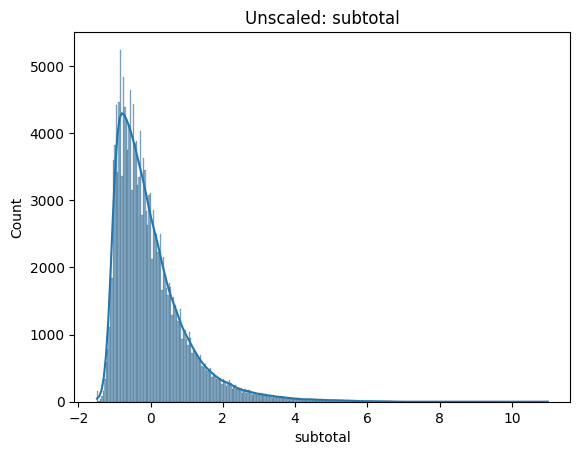

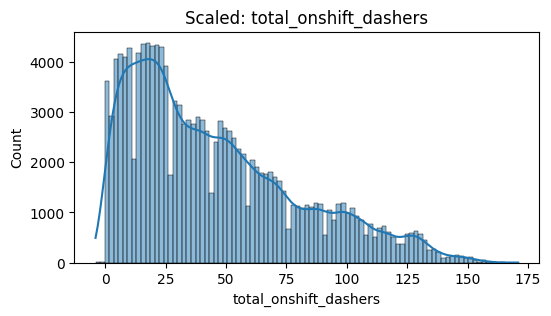

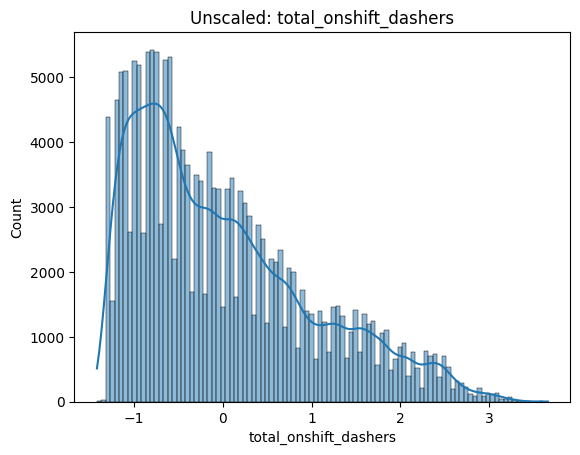

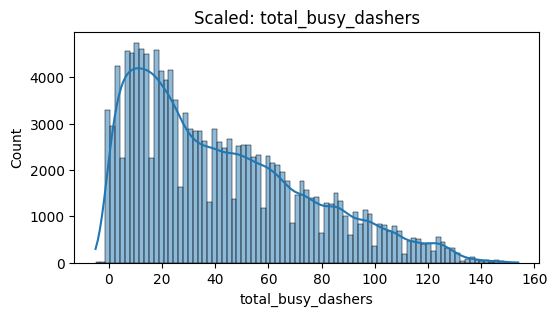

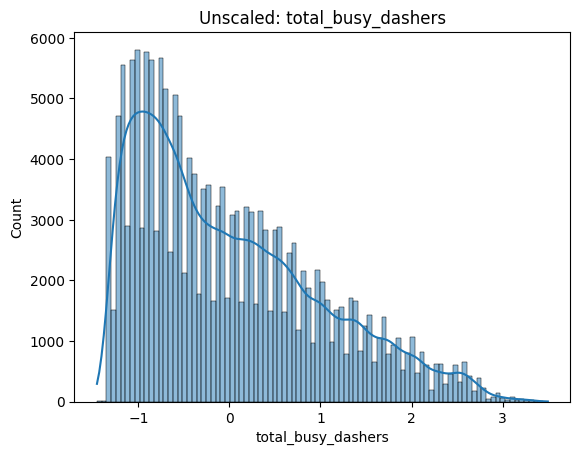

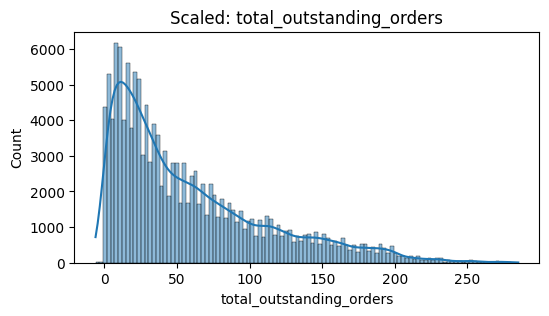

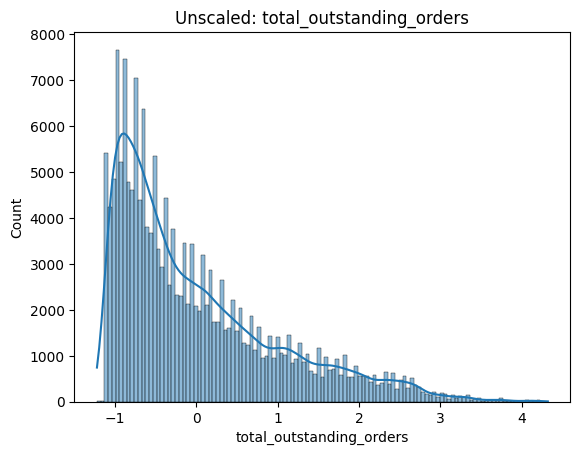

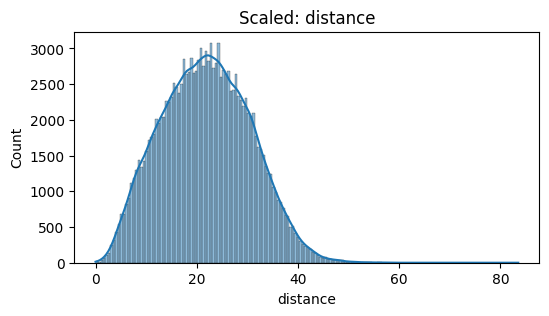

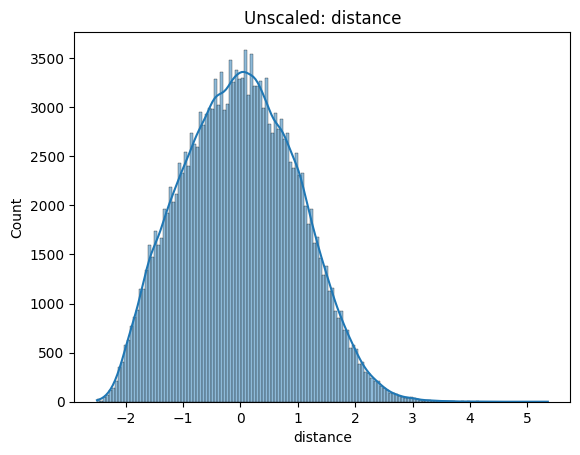

In [53]:
# Compare the scaled vs unscaled features used in the final model
selected = X_train.columns[rfe.support_]
for col in selected:
    plt.figure(figsize=(6, 3))
    sns.histplot(X_train[col], kde=True)
    plt.title(f"Scaled: {col}")
    plt.show()

    sns.histplot(porter_data[col], kde=True)
    plt.title(f"Unscaled: {col}")
    plt.show()



Additionally, we can analyse the effect of a unit change in a feature. In other words, because we have scaled the features, a unit change in the features will not translate directly to the model. Use scaled and unscaled coefficients to find how will a unit change in a feature affect the target.

A unit increase in 'distance' changes delivery_time_min by 0.4786 minutes.


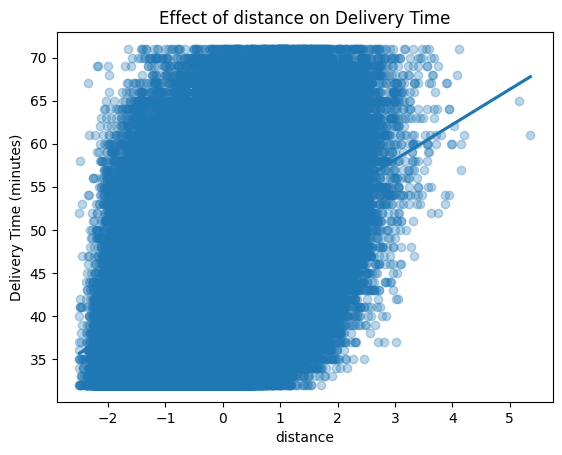

In [54]:
# Analyze the effect of a unit change in a feature, say 'total_items'
coef_index = list(selected).index('distance')
coef_value = model.coef_[coef_index]
print(f"A unit increase in 'distance' changes delivery_time_min by {coef_value:.4f} minutes.")

sns.regplot(x='distance', y='delivery_time_min', data=porter_data, scatter_kws={'alpha':0.3})
plt.title("Effect of distance on Delivery Time")
plt.xlabel("distance")
plt.ylabel("Delivery Time (minutes)")
plt.show()


Note:
The coefficients on the original scale might differ greatly in magnitude from the scaled coefficients, but they both describe the same relationships between variables.

Interpretation is key: Focus on the direction and magnitude of the coefficients on the original scale to understand the impact of each variable on the response variable in the original units.

Include conclusions in your report document.

## Subjective Questions <font color = red>[20 marks]</font>

Answer the following questions only in the notebook. Include the visualisations/methodologies/insights/outcomes from all the above steps in your report.

#### Subjective Questions based on Assignment

##### **Question 1.** <font color = red>[2 marks]</font> <br>

Are there any categorical variables in the data? From your analysis of the categorical variables from the dataset, what could you infer about their effect on the dependent variable?

**Answer:**
>Yes, they affect delivery time based on order type.



---



##### **Question 2.** <font color = red>[1 marks]</font> <br>
What does `test_size = 0.2` refer to during splitting the data into training and test sets?

**Answer:**
>test_size = 0.2 means 20% of the data is used for testing, and 80% for training.



---



##### **Question 3.** <font color = red>[1 marks]</font> <br>
Looking at the heatmap, which one has the highest correlation with the target variable?  

**Answer:**
>subtotal has highest correlation with delivery_time_min.



---



##### **Question 4.** <font color = red>[2 marks]</font> <br>
What was your approach to detect the outliers? How did you address them?

**Answer:**

>Used IQR method to detect and remove outliers from delivery_time_min.



---



##### **Question 5.** <font color = red>[2 marks]</font> <br>
Based on the final model, which are the top 3 features significantly affecting the delivery time?

**Answer:**
>Top 3 features affecting delivery time: subtotal, distance, and total_outstanding_orders, based on the final model.



---



#### General Subjective Questions

##### **Question 6.** <font color = red>[3 marks]</font> <br>
Explain the linear regression algorithm in detail

**Answer:**
>Linear regression is a simple way to predict a number using other known values. It draws the best straight line through the data to show the relationship between the inputs and the result. Each input gets a value (called a coefficient) that shows how much it affects the final answer. The model tries to make the difference between the real and predicted numbers as small as possible. It works best when the relationship between the values is straight and clear. People use it because it’s fast, easy to understand, and good for simple prediction tasks.




---



##### **Question 7.** <font color = red>[2 marks]</font> <br>
Explain the difference between simple linear regression and multiple linear regression

**Answer:**
>*   Simple linear regression uses one thing to make a prediction.
*   Multiple linear regression uses two or more things to make a better prediction.              



---



##### **Question 8.** <font color = red>[2 marks]</font> <br>
What is the role of the cost function in linear regression, and how is it minimized?

**Answer:**
>


1.   The cost function tells how far off the predictions are from real values.
2.   The goal is to make this number as small as possible using methods like gradient descent, so the model gives better and more accurate results.




---



##### **Question 9.** <font color = red>[2 marks]</font> <br>
Explain the difference between overfitting and underfitting.



**Answer:**

>Overfitting means the model remembers the training data too well and does badly on new data. Underfitting means the model is too simple and doesn’t learn enough, so it does badly on both training and new data.



---



##### **Question 10.** <font color = red>[3 marks]</font> <br>
How do residual plots help in diagnosing a linear regression model?

**Answer:**
>Residual plots show how far predictions are from actual values. If points are randomly spread, the model fits well. If there's a pattern, the model might be missing something or not working right. They help check if the model’s errors are small, even, and random.